170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 57s 0us/step


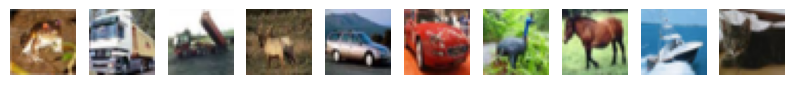

In [ ]:
#Step 0: Visualise the Dataset

import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10

(X_train, y_train), (_, _) = cifar10.load_data()

plt.figure(figsize=(10, 2))

for i in range(10):

    plt.subplot(1, 10, i+1)

    plt.imshow(X_train[i])

    plt.axis('off')

plt.show()

In [ ]:
#step 1- Load in CIFAR-10

import tensorflow as tf

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras.applications.densenet import preprocess_input

from tensorflow.keras.utils import to_categorical

#load in CIFAR-10

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [ ]:
#step 2.1 - (fix) Resize for MobileNetV2 (224x224)

#fix: resize images one batch at a time using tf.data for memory efficiency

#from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

#from tensorflow.keras.applications.resnet50 import preprocess_input

#from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.applications.densenet import preprocess_input

BATCH_SIZE = 32

IMG_SIZE = (224, 224)

#preprocessing function for map

def preprocess(image, label):

    image = tf.image.resize(image, IMG_SIZE)

    image = preprocess_input(image)  # scale to [-1, 1]

    return image, tf.one_hot(label[0], 10)

#train dataset

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#test dataset

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

from tensorflow.keras.applications.densenet import DenseNet121

#load MobileNetV2 base model

base_model_densenet121 = DenseNet121(weights='imagenet',

                         include_top=False, #without top classification head

                         input_shape=(224, 224, 3))

base_model_densenet121.trainable = False  #going with freezed pretrained layers (for now)

# -----------------------------------------------------------------------
# OTHER MODELS - uncomment the block for the model you want to use.
# Also swap variable names in Steps 4-8:
#   base_model_densenet121  ->  e.g. base_model_mobilenetv2
#   model_densenet121       ->  e.g. model_mobilenetv2
# In step 1, keep only the matching preprocess_input import active.
# -----------------------------------------------------------------------

## --- MobileNetV2 ---
#from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
#base_model_mobilenetv2 = MobileNetV2(weights='imagenet',
#                          include_top=False,
#                          input_shape=(224, 224, 3))
#base_model_mobilenetv2.trainable = False

## --- DenseNet169 ---
#from tensorflow.keras.applications.densenet import DenseNet169
#base_model_densenet169 = DenseNet169(weights='imagenet',
#                          include_top=False,
#                          input_shape=(224, 224, 3))
#base_model_densenet169.trainable = False

## --- DenseNet201 ---
#from tensorflow.keras.applications.densenet import DenseNet201
#base_model_densenet201 = DenseNet201(weights='imagenet',
#                          include_top=False,
#                          input_shape=(224, 224, 3))
#base_model_densenet201.trainable = False

## --- ResNet50 ---
#from tensorflow.keras.applications.resnet50 import ResNet50
#base_model_resnet50 = ResNet50(weights='imagenet',
#                    include_top=False,
#                    input_shape=(224, 224, 3))
#base_model_resnet50.trainable = False

## --- ResNet152 ---
#from tensorflow.keras.applications.resnet import ResNet152
#base_model_resnet152 = ResNet152(weights='imagenet',
#                      include_top=False,
#                      input_shape=(224, 224, 3))
#base_model_resnet152.trainable = False

## --- VGG16 ---
#from tensorflow.keras.applications.vgg16 import VGG16
#base_model_vgg16 = VGG16(weights='imagenet',
#               include_top=False,
#               input_shape=(224, 224, 3))
#base_model_vgg16.trainable = False

## --- VGG19 ---
#from tensorflow.keras.applications.vgg19 import VGG19
#base_model_vgg19 = VGG19(weights='imagenet',
#               include_top=False,
#               input_shape=(224, 224, 3))
#base_model_vgg19.trainable = False

# -----------------------------------------------------------------------

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
#Step 4 - Adding our custom top classification head

from tensorflow.keras import layers, models

#custom head

model_densenet121 = models.Sequential([

    base_model_densenet121,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')  # 10 classes for CIFAR-10

])

#compile the model

model_densenet121.compile(optimizer='adam',

              loss='categorical_crossentropy',

              metrics=['accuracy'])

In [5]:
#Step 5 - Train

#run fit()

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#optional but helpful callbacks

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

checkpoint = ModelCheckpoint('mobilenetv2_cifar10.h5', save_best_only=True)

#train the model

history = model_densenet121.fit(

    train_ds,

    validation_data=test_ds,

    epochs=10,

    callbacks=[early_stop, checkpoint]

)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7194 - loss: 0.8412

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 248s 138ms/step - accuracy: 0.7978 - loss: 0.6060 - val_accuracy: 0.8779 - val_loss: 0.3572
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8506 - loss: 0.4434

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 176s 112ms/step - accuracy: 0.8535 - loss: 0.4363 - val_accuracy: 0.8890 - val_loss: 0.3316
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8649 - loss: 0.4104

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 174s 111ms/step - accuracy: 0.8657 - loss: 0.4040 - val_accuracy: 0.8912 - val_loss: 0.3231
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8703 - loss: 0.3873

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 174s 111ms/step - accuracy: 0.8704 - loss: 0.3853 - val_accuracy: 0.8935 - val_loss: 0.3175
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 172s 110ms/step - accuracy: 0.8740 - loss: 0.3696 - val_accuracy: 0.8917 - val_loss: 0.3235
Epoch 6/10
1562/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8779 - loss: 0.3656

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 172s 110ms/step - accuracy: 0.8774 - loss: 0.3636 - val_accuracy: 0.8936 - val_loss: 0.3172
Epoch 7/10
1562/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8797 - loss: 0.3578

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 185s 118ms/step - accuracy: 0.8793 - loss: 0.3528 - val_accuracy: 0.8922 - val_loss: 0.3163
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8827 - loss: 0.3487

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 185s 118ms/step - accuracy: 0.8837 - loss: 0.3434 - val_accuracy: 0.8927 - val_loss: 0.3125
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8835 - loss: 0.3399

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 173s 110ms/step - accuracy: 0.8853 - loss: 0.3343 - val_accuracy: 0.8952 - val_loss: 0.3087
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 171s 109ms/step - accuracy: 0.8867 - loss: 0.3267 - val_accuracy: 0.8963 - val_loss: 0.3180


In [6]:
#Step 6 - run a final performance evaluation (higher the better)

# Q(a) Find the test accuracy for the model.

loss, acc = model_densenet121.evaluate(test_ds, verbose=1)

print(f"Test Accuracy: {acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 97ms/step - accuracy: 0.8952 - loss: 0.3087
Test Accuracy: 0.90


In [8]:
#Step 7 - fine tune MobileNetV2 for higher Accuracy (optional)

# Q(b)Fine-tune the model using user-defined number of epochs. Try 5, 10, 15.

#unfreeze the base model

base_model_densenet121.trainable = True

#recompile with a lower learning rate

model_densenet121.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),

              loss='categorical_crossentropy',

              metrics=['accuracy'])

#fine-tune the model

fine_tune_epochs = 5

total_epochs = 10 + fine_tune_epochs

history_fine = model_densenet121.fit(

    train_ds,

    validation_data=test_ds,

    epochs=total_epochs,

    initial_epoch=len(history.epoch),

    callbacks=[early_stop, checkpoint]

)

Epoch 11/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.8744 - loss: 0.3875

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 903s 474ms/step - accuracy: 0.8844 - loss: 0.3605 - val_accuracy: 0.9312 - val_loss: 0.2013
Epoch 12/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.9309 - loss: 0.2040

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 622s 387ms/step - accuracy: 0.9348 - loss: 0.1929 - val_accuracy: 0.9421 - val_loss: 0.1803
Epoch 13/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.9579 - loss: 0.1222

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 605s 387ms/step - accuracy: 0.9608 - loss: 0.1151 - val_accuracy: 0.9472 - val_loss: 0.1758
Epoch 14/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 612s 392ms/step - accuracy: 0.9758 - loss: 0.0722 - val_accuracy: 0.9494 - val_loss: 0.1876
Epoch 15/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 604s 386ms/step - accuracy: 0.9847 - loss: 0.0472 - val_accuracy: 0.9502 - val_loss: 0.1838


313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - accuracy: 0.9472 - loss: 0.1758
Test Accuracy: 0.95


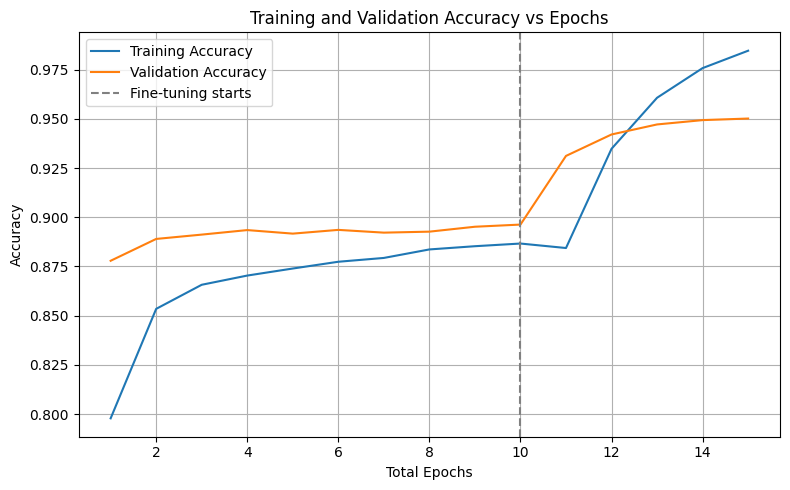

In [9]:
#Step 8 - evaluate again (higher the better)

# Q(c) Find out test accuracy.

loss, acc = model_densenet121.evaluate(test_ds, verbose=1)

print(f"Test Accuracy: {acc:.2f}")

# Q(c) Plot final accuracies (training and validation) vs total epochs

total_acc     = history.history['accuracy']     + history_fine.history['accuracy']
total_val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

plt.figure(figsize=(8, 5))
plt.plot(range(1, total_epochs + 1), total_acc,     label='Training Accuracy')
plt.plot(range(1, total_epochs + 1), total_val_acc, label='Validation Accuracy')
plt.axvline(x=10, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Training and Validation Accuracy vs Epochs')
plt.xlabel('Total Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()